In [1]:

import os, glob, shutil, subprocess

RELEASE = ('https://github.com/marchettialessio/Human-Activity-Recognition-with-Wi-Fi'
           '/releases/download/assets-v1')

DATASET_ZIP = 'doppler_traces.zip'
DATASET_SIZE = 799057851          # exact size in bytes: guards against a truncated download


def ok_size(path, size):
    return os.path.isfile(path) and os.path.getsize(path) == size


def _resume_cmd(url, dst):
    """wget on Colab, curl elsewhere: both resume a partial file instead of restarting it."""
    if shutil.which('wget'):
        return ['wget', '-q', '--show-progress', '-c', '-O', dst, url]
    if shutil.which('curl'):
        return ['curl', '-fL', '-#', '-C', '-', '-o', dst, url]
    raise RuntimeError('neither wget nor curl available')


def fetch(name, size, out_dir='/content', tries=3):
    """Download a Release asset and check its exact size: a truncated file would break torch.load
       or, worse, make the training silently restart from epoch 0."""
    dst = os.path.join(out_dir, name)
    for k in range(tries):
        if ok_size(dst, size):
            return dst
        if os.path.isfile(dst) and os.path.getsize(dst) > size:
            os.remove(dst)        # corrupt (too big): resuming would never fix it
        r = subprocess.run(_resume_cmd(f'{RELEASE}/{name}', dst))
        got = os.path.getsize(dst) if os.path.isfile(dst) else 0
        if ok_size(dst, size):
            return dst
        print(f'  {name}: attempt {k + 1}/{tries} incomplete '
              f'({got}/{size} bytes, exit={r.returncode})')
    raise RuntimeError(f'{name}: download failed, re-run this cell (the partial file is resumed)')


if not os.path.isdir('/content/doppler_traces'):
    z = fetch(DATASET_ZIP, DATASET_SIZE)
    !unzip -q -o "{z}" -d /content
    # the zip may unpack into a subfolder: normalize to /content/doppler_traces
    if not os.path.isdir('/content/doppler_traces'):
        cand = glob.glob('/content/**/doppler_traces', recursive=True)
        assert cand, 'doppler_traces not found inside the zip'
        !mv "{cand[0]}" /content/doppler_traces

assert os.path.isdir('/content/doppler_traces'), 'dataset not found after download'
print('Dataset:', os.path.isdir('/content/doppler_traces'))


Dataset: True


## UTILITY

In [2]:
import glob
import os
import numpy as np
import pickle
import math as mt
import shutil

def convert_to_number(lab, csi_label_dict):
    lab_num = np.argwhere(np.asarray(csi_label_dict) == lab)[0][0]
    return lab_num


def create_windows(csi_list, labels_list, sample_length, stride_length):
    csi_matrix_stride = []
    labels_stride = []
    for i in range(len(labels_list)):
        csi_i = csi_list[i]
        label_i = labels_list[i]
        len_csi = csi_i.shape[1]
        for ii in range(0, len_csi - sample_length, stride_length):
            csi_matrix_stride.append(csi_i[:, ii:ii+sample_length])
            labels_stride.append(label_i)
    return csi_matrix_stride, labels_stride

def create_windows_antennas(csi_list, labels_list, sample_length, stride_length, remove_mean=False):
    # --- split each activity into windows (keep all antennas together)
    csi_matrix_stride = []
    labels_stride = []
    for i in range(len(labels_list)):        # iterate over the N ACTIVITIES
        csi_i = csi_list[i]                  # Doppler spectrum (all antennas) of activity i
        label_i = labels_list[i]             # its label (a single value)
        len_csi = csi_i.shape[2]             # time length = number of available Doppler columns
        # --- sliding window: start 0, step stride_length, stop when no full window fits
        for ii in range(0, len_csi - sample_length, stride_length):
            csi_wind = csi_i[:, :, ii:ii + sample_length, ...]   # crop [ii, ii+sample_length)
            if remove_mean:
                # optional: subtract the mean over time (axis 2), removes the window offset
                csi_mean = np.mean(csi_wind, axis=2, keepdims=True)
                csi_wind = csi_wind - csi_mean
            csi_matrix_stride.append(csi_wind)   # +1 sample (one window)
            labels_stride.append(label_i)        # +1 label = the one of activity i
    return csi_matrix_stride, labels_stride

## GENERATE DATASET

In [3]:
# --- dataset generation (single train/test method)
#     complete=False -> temporal 60/20/20 split per activity ; complete=True -> whole sequence into "complete"

def generate_dataset(data_dir, list_subdir, num_packets, sliding, window_length,
                   stride_length, labels_activities, n_tot, complete=False):
    """
    data_dir         : root folder of the data (Doppler spectra)
    list_subdir      : experiment subfolders, comma-separated (e.g. "S1a,S1b,S1c")
    num_packets      : n. of Wi-Fi packets used for one STFT (e.g. 31)
    sliding          : step (in packets) between two consecutive STFTs
    window_length    : n. of Doppler columns per window (network input, e.g. 340)
    stride_length    : step between two consecutive windows
    labels_activities: activities considered, e.g. "E,J,L,R,W" (the index becomes the label)
    n_tot            : n. of spatial streams * n. of antennas (channels per activity, e.g. 4)
    complete         : False -> train/val/test split ; True -> single "complete" set
    """
    # --- label dictionary: E,J,L,R,W to list
    csi_label_dict = []
    for lab_act in labels_activities.split(','):
        csi_label_dict.append(lab_act)
    activities = np.asarray(labels_activities)   # only used to build output folder/file names

    # --- main loop: one subfolder at a time
    for subdir in list_subdir.split(','):
        exp_dir = data_dir + subdir + '/'  # full path of the experiment folder

        # --- output folder names
        path_train = exp_dir + 'train_antennas_' + str(activities)
        path_val = exp_dir + 'val_antennas_' + str(activities)
        path_test = exp_dir + 'test_antennas_' + str(activities)
        path_complete = exp_dir + 'complete_antennas_' + str(activities)

        # --- folder preparation (different logic in the two modes)
        if not complete:
            # train mode: prepare train/val/test (empty them if they exist, else create)
            for pat in [path_train, path_val, path_test]:
                if os.path.exists(pat):
                    for f in glob.glob(pat + '/*'):
                        os.remove(f)
                else:
                    os.mkdir(pat)
            # remove any "complete" from previous runs
            if os.path.exists(path_complete):
                shutil.rmtree(path_complete)
        else:
            # test mode: fully delete train/val/test and prepare "complete"
            # careful: never on a subdir used for training, its split would be erased
            for pat in [path_train, path_val, path_test]:
                if os.path.exists(pat):
                    shutil.rmtree(pat)
            if os.path.exists(path_complete):
                for f in glob.glob(path_complete + '/*'):
                    os.remove(f)
            else:
                os.mkdir(path_complete)

        # --- input file collection: files starting with 'S', without .txt, sorted (n_tot antennas end up consecutive)
        names = []
        all_files = os.listdir(exp_dir)
        for i in range(len(all_files)):
            if all_files[i].startswith('S'):
                names.append(all_files[i][:-4])
        names.sort()

        # --- grouping by activity: each activity = n_tot consecutive files (one per antenna)
        csi_matrices = []   # list of arrays (n_tot, doppler_freq, time) -> one per activity
        labels = []         # numeric label of each activity
        lengths = []        # temporal duration (n. of Doppler columns) of each activity
        label = 'null'
        prev_label = label
        csi_matrix = []     # buffer: the antennas of the current activity
        processed = False
        for i_name, name in enumerate(names):
            # --- at every multiple of n_tot (not first) an antenna group is complete
            if i_name % n_tot == 0 and i_name != 0 and processed:
                ll = csi_matrix[0].shape[1]
                for i_ant in range(1, n_tot):
                    if ll != csi_matrix[i_ant].shape[1]:
                        break
                lengths.append(ll)
                csi_matrices.append(np.asarray(csi_matrix))  # stack -> (n_tot, freq, time)
                labels.append(label)
                csi_matrix = []

            label = name[4]  # the label = 5th character of the file name
            if label not in csi_label_dict:
                processed = False
                continue
            processed = True
            print(name)

            label = convert_to_number(label, csi_label_dict)
            if i_name % n_tot == 0:
                prev_label = label
            elif label != prev_label:
                print('error in ' + str(name))
                break

            # --- load single-antenna Doppler spectrum, remove per-column mean
            name_file = exp_dir + name + '.txt'
            with open(name_file, "rb") as fp:
                stft_sum_1 = pickle.load(fp)
            stft_sum_1_mean = stft_sum_1 - np.mean(stft_sum_1, axis=0, keepdims=True)
            csi_matrix.append(stft_sum_1_mean.T)  # -> (doppler_freq, time)

        # --- close the LAST group (common to both modes)
        error = False
        if processed:
            if len(csi_matrix) < n_tot:
                print('error in ' + str(name))
            ll = csi_matrix[0].shape[1]
            for i_ant in range(1, n_tot):
                if ll != csi_matrix[i_ant].shape[1]:
                    print('error in ' + str(name))
                    error = True
            if not error:
                lengths.append(ll)
                csi_matrices.append(np.asarray(csi_matrix))
                labels.append(label)

        if error:
            continue

        # --- dispatch: split (train) or whole sequence (complete)
        if not complete:
            # train mode: temporal 60/20/20 split per activity
            lengths = np.asarray(lengths)
            csi_train, csi_val, csi_test = [], [], []
            length_train, length_val, length_test = [], [], []
            for i in range(len(labels)):
                ll = lengths[i]
                # train: first 60%
                train_len = int(np.floor(ll * 0.6))
                length_train.append(train_len)
                csi_train.append(csi_matrices[i][:, :, :train_len])
                # val: next 20%, with a ceil(num_packets/sliding) gap to avoid overlap
                start_val = train_len + mt.ceil(num_packets / sliding)
                val_len = int(np.floor(ll * 0.2))
                length_val.append(val_len)
                csi_val.append(csi_matrices[i][:, :, start_val:start_val + val_len])
                # test: remainder, after another gap
                start_test = start_val + val_len + mt.ceil(num_packets / sliding)
                length_test.append(ll - val_len - train_len - 2 * mt.ceil(num_packets / sliding))
                csi_test.append(csi_matrices[i][:, :, start_test:])

            list_sets_name = ['train', 'val', 'test']
            list_sets = [csi_train, csi_val, csi_test]
            list_sets_lengths = [length_train, length_val, length_test]

            # --- windowing + saving for each of the 3 sets
            for set_idx in range(3):
                csi_matrices_set, labels_set = create_windows_antennas(
                    list_sets[set_idx], labels, window_length, stride_length, remove_mean=False)
                num_windows = np.floor(
                    (np.asarray(list_sets_lengths[set_idx]) - window_length) / stride_length + 1)
                if not len(csi_matrices_set) == np.sum(num_windows):
                    print('ERROR - shapes mismatch')
                _save_windows(exp_dir, list_sets_name[set_idx], str(activities),
                                csi_matrices_set, labels_set, num_windows)
        else:
            # test mode: no split, the whole sequence into "complete"
            csi_complete = [csi_matrices[i] for i in range(len(labels))]
            csi_matrices_wind, labels_wind = create_windows_antennas(
                csi_complete, labels, window_length, stride_length, remove_mean=False)
            num_windows = np.floor((np.asarray(lengths) - window_length) / stride_length + 1)
            if not len(csi_matrices_wind) == np.sum(num_windows):
                print('ERROR - shapes mismatch')
            _save_windows(exp_dir, 'complete', str(activities),
                            csi_matrices_wind, labels_wind, num_windows)


def _save_windows(exp_dir, set_name, activities_str, csi_windows, labels_windows, num_windows):
    """Save the windows of a set + the summary files (labels_/files_/num_windows_)."""
    suffix = '.txt'
    names_set = []
    for ii in range(len(csi_windows)):
        name_file = exp_dir + set_name + '_antennas_' + activities_str + '/' + str(ii) + suffix
        names_set.append(name_file)
        with open(name_file, "wb") as fp:            # one window per file (pickle)
            pickle.dump(csi_windows[ii], fp)
    # labels_*: label of each window
    with open(exp_dir + '/labels_' + set_name + '_antennas_' + activities_str + suffix, "wb") as fp:
        pickle.dump(labels_windows, fp)
    # files_*: paths of the saved windows (used by the loader)
    with open(exp_dir + '/files_' + set_name + '_antennas_' + activities_str + suffix, "wb") as fp:
        pickle.dump(names_set, fp)
    # num_windows_*: n. of windows per activity (to reconstruct the antenna groups)
    with open(exp_dir + '/num_windows_' + set_name + '_antennas_' + activities_str + suffix, "wb") as fp:
        pickle.dump(num_windows, fp)


# --- parameters + call (non-complete mode: train/val/test split)
data_dir = '/content/doppler_traces/'   # root folder of the data (dataset unpacked on Colab)
list_subdir = 'S1a,S1b,S1c'             # experiment subfolders (comma-separated)
num_packets = 31                        # n. of Wi-Fi packets per STFT
sliding = 1                             # step (in packets) between two STFTs
window_length = 340                     # n. of Doppler columns per window (network input)
stride_length = 30                      # step between two consecutive windows
labels_activities = 'E,J,L,R,W'         # activities (the index = label: E->0, J->1, ...)
n_tot = 4                               # n. of streams * n. of antennas

generate_dataset(data_dir, list_subdir, num_packets, sliding, window_length,
               stride_length, labels_activities, n_tot, complete=False)

S1a_E_stream_0
S1a_E_stream_1
S1a_E_stream_2
S1a_E_stream_3
S1a_J1_stream_0
S1a_J1_stream_1
S1a_J1_stream_2
S1a_J1_stream_3
S1a_J2_stream_0
S1a_J2_stream_1
S1a_J2_stream_2
S1a_J2_stream_3
S1a_L_stream_0
S1a_L_stream_1
S1a_L_stream_2
S1a_L_stream_3
S1a_R_stream_0
S1a_R_stream_1
S1a_R_stream_2
S1a_R_stream_3
S1a_W_stream_0
S1a_W_stream_1
S1a_W_stream_2
S1a_W_stream_3
S1b_E_stream_0
S1b_E_stream_1
S1b_E_stream_2
S1b_E_stream_3
S1b_J1_stream_0
S1b_J1_stream_1
S1b_J1_stream_2
S1b_J1_stream_3
S1b_J2_stream_0
S1b_J2_stream_1
S1b_J2_stream_2
S1b_J2_stream_3
S1b_L_stream_0
S1b_L_stream_1
S1b_L_stream_2
S1b_L_stream_3
S1b_R_stream_0
S1b_R_stream_1
S1b_R_stream_2
S1b_R_stream_3
S1b_W_stream_0
S1b_W_stream_1
S1b_W_stream_2
S1b_W_stream_3
ERROR - shapes mismatch
ERROR - shapes mismatch
ERROR - shapes mismatch
S1c_E_stream_0
S1c_E_stream_1
S1c_E_stream_2
S1c_E_stream_3
S1c_J1_stream_0
S1c_J1_stream_1
S1c_J1_stream_2
S1c_J1_stream_3
S1c_J2_stream_0
S1c_J2_stream_1
S1c_J2_stream_2
S1c_J2_stream_3
S1c_

## NEURAL NETWORK — CSI_network (PyTorch)
PyTorch version of the SHARP network (`CSI_network.py` + `network_utility.py`) with the single-antenna loader.

In [4]:
# --- inception-residual network, single antenna; input (1, 340, 100) = (channel, TIME, DOPPLER)
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBnRelu(nn.Module):
    # --- conv + (optional BatchNorm) + ReLU; in the SHARP model bn is always off
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding='same', activation=True, batchNormalization = False):
        super().__init__()
        # padding='same' works only with stride=1: with stride=2 we pass an integer padding
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_ch)
        self.batchNormalization = batchNormalization
        self.act = nn.ReLU()
        self.activation = activation

    def forward(self, x):
        x = self.conv(x)
        if self.batchNormalization:
            x = self.bn(x)
        if self.activation:
            x = self.act(x)
        return x


class ReductionABlockSmall(nn.Module):
    """
    Input (N,1,340,100) -> output (N,15,170,50).
    """
    def __init__(self, in_ch):
        super().__init__()
        # --- branch 1: maxpool 2x2 stride 2 -> halves H,W, 1 channel
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # --- branch 2: conv 5 filters 2x2 stride 2 -> (N,5,170,50)
        self.b2 = ConvBnRelu(in_ch, 5, kernel_size=2, stride=2, padding=0)
        # --- branch 3: 1x1 same -> 2x2 same -> 4x4 stride2
        self.b3_1 = ConvBnRelu(in_ch, 3, kernel_size=1, stride=1, padding='same')
        self.b3_2 = ConvBnRelu(3, 6, kernel_size=2, stride=1, padding='same')
        # --- 4x4 stride2 'same' -> padding=1 to replicate TF 170x50 output exactly
        self.b3_3 = ConvBnRelu(6, 9, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        x1 = self.pool(x)          # (N,1,170,50)
        x2 = self.b2(x)            # (N,5,170,50)
        x3 = self.b3_1(x)
        x3 = self.b3_2(x3)
        x3 = self.b3_3(x3)         # (N,9,170,50)
        return torch.cat([x1, x2, x3], dim=1)   # (N,15,170,50)


class Projection_Head(nn.Module):
    def __init__(self, input_dim=25500, hidden_dim=512, output_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = F.normalize(x, p=2, dim=1)      # L2 normalization
        return x

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Learning Loss.
    Prende in input gli embedding (L2-normalized) e le relative etichette.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        batch_size = features.shape[0]

        # matrix of cosine similarity, because of the normalization it's a dot product.
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # mask for the positive samples
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        # remove the self similarity
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # for numerical stability
        sim_max, _ = torch.max(similarity_matrix, dim=1, keepdim=True)
        logits = similarity_matrix - sim_max.detach()

        # At the denominator I sum the exponential value
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-20)

        # mean of the positive values
        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-20)

        # average loss over all the batch
        loss = -mean_log_prob_pos.mean()

        return loss


class SupervisedContrastive(nn.Module):
    def __init__(self, input_channels, input_hw=(340, 100), hidden_dim=512, output_dim=128):
        super().__init__()
        self.reduction = ReductionABlockSmall(input_channels)
        # from 15 to 3 feature map
        self.conv4 = ConvBnRelu(15, 3, kernel_size=1, stride=1, padding='same')
        # flatten dim from the shapes (170x50 after the reduction)
        h, w = input_hw
        h2, w2 = h // 2, w // 2          # 170, 50
        self.flat_dim = 3 * h2 * w2      # 3*170*50 = 25500
        self.head = Projection_Head(input_dim=25500, hidden_dim=hidden_dim, output_dim=output_dim)
        self._init_weights()

    def _init_weights(self):
        # --- Xavier/Glorot init as in Keras (the PyTorch default would be Kaiming)
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Extract features
        x = self.reduction(x)
        x = self.conv4(x)
        # Flatten keeping the batch dim
        x = torch.flatten(x, start_dim=1)
        # Embedding z
        z = self.head(x)
        return z


class CSINetworkIncRes(nn.Module):
    # --- classifier: reduction block + 1x1 conv + dropout + linear
    def __init__(self, input_channels, num_classes, input_hw=(340, 100)):
        super().__init__()
        self.reduction = ReductionABlockSmall(input_channels)
        # from 15 to 3 feature map
        self.conv4 = ConvBnRelu(15, 3, kernel_size=1, stride=1, padding='same')
        # flatten dim from the shapes (170x50 after the reduction)
        h, w = input_hw
        h2, w2 = h // 2, w // 2          # 170, 50
        self.flat_dim = 3 * h2 * w2      # 3*170*50 = 25500
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(self.flat_dim, num_classes)   # logits, no softmax
        self._init_weights()

    def _init_weights(self):
        # --- Xavier/Glorot init as in Keras (the PyTorch default would be Kaiming)
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.reduction(x)
        x = self.conv4(x)
        x = torch.flatten(x, start_dim=1)   # Flatten keeping the batch dim
        x = self.dropout(x)
        x = self.fc(x)                      # logits
        return x

## DATASET LOADER (PyTorch)

In [5]:
# --- single-antenna dataset + DataLoader (shuffle, batch and prefetch handled by the loader)
from torch.utils.data import Dataset, DataLoader


def expand_antennas(file_names, labels, num_antennas):
    # --- per-antenna expansion: each window -> num_antennas single-antenna samples
    file_names_expanded = [item for item in file_names for _ in range(num_antennas)]
    labels_expanded = [item for item in labels for _ in range(num_antennas)]
    stream_ant = np.tile(np.arange(num_antennas), len(labels))
    return file_names_expanded, labels_expanded, stream_ant


class CSIDatasetSingle(Dataset):
    """Single-antenna: returns (x, y_activity)."""
    def __init__(self, csi_files, labels, stream_ant):
        self.files = csi_files
        self.labels = labels
        self.stream_ant = list(stream_ant)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        with open(self.files[idx], "rb") as fp:
            matrix_csi = pickle.load(fp)          # (n_tot, 100, 340)
        stream = self.stream_ant[idx]
        m = matrix_csi[stream, ...].T             # 1 antenna -> (340, 100)  time x doppler
        m = np.ascontiguousarray(m[np.newaxis, ...])   # (1, 340, 100)
        x = torch.from_numpy(m).float()
        # label as long: required by nn.CrossEntropyLoss (not one-hot)
        y = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return x, y


def make_dataloader(csi_files, labels, stream_ant, batch_size, shuffle):
    # shuffle=True only in training
    ds = CSIDatasetSingle(csi_files, labels, stream_ant)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, drop_last=False)

##TRAINING PARAMETERS

In [6]:
# --- training setup: parameters, window indices, DataLoader
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

# --- parameters (consistent with the dataset generation)
subdirs_training = 'S1a,S1b,S1c'   # sessions used for train/val/test
csi_act = labels_activities        # MUST match the generated folder names ('E,J,L,R,W')
feature_length = 100               # Doppler bins (feature height)
sample_length = 340                # time (width)
channels = 1                       # single antenna
batch_size = 32
num_antennas = n_tot               # 4
name_base = 'single_ant'

activities = np.asarray([a for a in csi_act.split(',')])
output_shape = activities.shape[0]                 # n. of classes = output neurons
labels_considered = np.arange(output_shape)        # [0..n_classes-1]
suffix = '.txt'

# --- index loading (labels/files) per session: only the window paths, not the data
labels_train, all_files_train = [], []
labels_val,   all_files_val   = [], []
labels_test,  all_files_test  = [], []
for sdir in subdirs_training.split(','):
    base = data_dir + sdir + '/'
    with open(base + 'labels_train_antennas_' + str(csi_act) + suffix, "rb") as fp:
        labels_train.extend(pickle.load(fp))
    with open(base + 'files_train_antennas_' + str(csi_act) + suffix, "rb") as fp:
        all_files_train.extend(pickle.load(fp))
    with open(base + 'labels_val_antennas_' + str(csi_act) + suffix, "rb") as fp:
        labels_val.extend(pickle.load(fp))
    with open(base + 'files_val_antennas_' + str(csi_act) + suffix, "rb") as fp:
        all_files_val.extend(pickle.load(fp))
    with open(base + 'labels_test_antennas_' + str(csi_act) + suffix, "rb") as fp:
        labels_test.extend(pickle.load(fp))
    with open(base + 'files_test_antennas_' + str(csi_act) + suffix, "rb") as fp:
        all_files_test.extend(pickle.load(fp))

# --- class filter + antenna expansion (train/val/test)
def filter_and_expand(all_files, labels):
    files_sel = [all_files[i] for i in range(len(labels)) if labels[i] in labels_considered]
    labels_sel = [labels[i] for i in range(len(labels)) if labels[i] in labels_considered]
    files_exp, labels_exp, stream_ant = expand_antennas(files_sel, labels_sel, num_antennas)
    return files_sel, labels_sel, files_exp, labels_exp, stream_ant

file_train_sel, labels_train_sel, file_train_exp, labels_train_exp, stream_ant_train = \
    filter_and_expand(all_files_train, labels_train)
file_val_sel, labels_val_sel, file_val_exp, labels_val_exp, stream_ant_val = \
    filter_and_expand(all_files_val, labels_val)
file_test_sel, labels_test_sel, file_test_exp, labels_test_exp, stream_ant_test = \
    filter_and_expand(all_files_test, labels_test)

# --- DataLoader: shuffle only in training
train_loader = make_dataloader(file_train_exp, labels_train_exp, stream_ant_train, batch_size, shuffle=True)
val_loader   = make_dataloader(file_val_exp,   labels_val_exp,   stream_ant_val,   batch_size, shuffle=False)
test_loader  = make_dataloader(file_test_exp,  labels_test_exp,  stream_ant_test,  batch_size, shuffle=False)

# --- device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


### 1. Pre-training with Supervised Contrastive Loss

In [7]:
#Contrastive model with supcon Loss
supcon_model = SupervisedContrastive(input_channels=channels, input_hw=(sample_length, feature_length)).to(device)
optimizer_pre = torch.optim.Adam(supcon_model.parameters(), lr=1e-4)
criterion_pre = SupConLoss(temperature=0.07)

name_supcon = 'supcon_checkpoint.torch'
epochs_pre = 20
start_epoch_pre = 0
best_pre_loss = float('inf')

# If it exist a model already trained, resume it
if os.path.exists(name_supcon):
    ckpt = torch.load(name_supcon, map_location=device)
    supcon_model.load_state_dict(ckpt['model_state_dict'])
    optimizer_pre.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch_pre = ckpt['epoch'] + 1
    best_pre_loss = ckpt['best_pre_loss']
    print(f'Resuming SupCon from epoch {start_epoch_pre}')

# training

for epoch in range(start_epoch_pre, epochs_pre):
    supcon_model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_pre.zero_grad()
        features = supcon_model(xb)
        loss = criterion_pre(features, yb)
        loss.backward()
        optimizer_pre.step()
        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader)
    print(f'SupCon Epoch {epoch+1}/{epochs_pre} - Loss: {avg_loss:.4f}')

    if avg_loss < best_pre_loss:
        best_pre_loss = avg_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': supcon_model.state_dict(),
            'optimizer_state_dict': optimizer_pre.state_dict(),
            'best_pre_loss': best_pre_loss
        }, name_supcon)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv2d(


SupCon Epoch 1/20 - Loss: 2.3065
SupCon Epoch 2/20 - Loss: 2.0405
SupCon Epoch 3/20 - Loss: 1.9104
SupCon Epoch 4/20 - Loss: 1.8297
SupCon Epoch 5/20 - Loss: 1.7887
SupCon Epoch 6/20 - Loss: 1.7702
SupCon Epoch 7/20 - Loss: 1.7635
SupCon Epoch 8/20 - Loss: 1.7629
SupCon Epoch 9/20 - Loss: 1.7543
SupCon Epoch 10/20 - Loss: 1.7587
SupCon Epoch 11/20 - Loss: 1.7778
SupCon Epoch 12/20 - Loss: 1.7544
SupCon Epoch 13/20 - Loss: 1.7543
SupCon Epoch 14/20 - Loss: 1.7467
SupCon Epoch 15/20 - Loss: 1.7679
SupCon Epoch 16/20 - Loss: 1.7546
SupCon Epoch 17/20 - Loss: 1.7526
SupCon Epoch 18/20 - Loss: 1.7524
SupCon Epoch 19/20 - Loss: 1.7658
SupCon Epoch 20/20 - Loss: 1.7591


### 2. Fine-tuning with Cross-Entropy Loss

In [8]:
finetune_model = CSINetworkIncRes(input_channels=channels, num_classes=output_shape, input_hw=(sample_length, feature_length)).to(device)

# Load supcon model
if os.path.exists(name_supcon):
    supcon_ckpt = torch.load(name_supcon, map_location=device)
    model_dict = finetune_model.state_dict()
    pretrained_dict = {k: v for k, v in supcon_ckpt['model_state_dict'].items() if k in model_dict and 'head' not in k}
    model_dict.update(pretrained_dict)
    finetune_model.load_state_dict(model_dict)
    print("Backbone loaded from SupCon pre-training.")

# freezing parameters of supcon model, except for the classification layer
for name, param in finetune_model.named_parameters():
    if "fc" not in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

# optimizer for the classification layer
optimizer_ft = torch.optim.Adam(filter(lambda p: p.requires_grad, finetune_model.parameters()), lr=1e-3)
criterion_ft = nn.CrossEntropyLoss()

name_ft = 'classification_head_best.torch'
patience_ft = 3
best_val_acc_ft = -1.0
best_val_loss_ft = float('inf')
epochs_no_improve_ft = 0
start_epoch_ft = 0

# load of the already trained finetuned model if it exist.
if os.path.exists(name_ft):
    ckpt = torch.load(name_ft, map_location=device)
    finetune_model.load_state_dict(ckpt['model_state_dict'])
    optimizer_ft.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch_ft = ckpt['epoch'] + 1
    best_val_acc_ft = ckpt['best_val_acc']
    print(f'Resuming Fine-tuning (Linear Probing) from epoch {start_epoch_ft}')

# training

for epoch in range(start_epoch_ft, 25):
    finetune_model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_ft.zero_grad()
        logits = finetune_model(xb)
        loss = criterion_ft(logits, yb)
        loss.backward()
        optimizer_ft.step()
    # validation
    finetune_model.eval()
    val_loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = finetune_model(xb)
            val_loss_sum += criterion_ft(logits, yb).item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)

    val_loss = val_loss_sum / total
    val_acc = correct / total
    print(f'FT Epoch {epoch+1} - val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')

    if val_acc > best_val_acc_ft:
        best_val_acc_ft = val_acc
        best_state = {k: v.cpu().clone() for k, v in finetune_model.state_dict().items()}

    if val_loss < best_val_loss_ft:
        best_val_loss_ft = val_loss
        epochs_no_improve_ft = 0
    else:
        epochs_no_improve_ft += 1

    # saving of the best model
    torch.save({
        'epoch': epoch,
        'model_state_dict': finetune_model.state_dict(),
        'optimizer_state_dict': optimizer_ft.state_dict(),
        'best_val_acc': best_val_acc_ft,
        'best_val_loss': best_val_loss_ft,
        'epochs_no_improve': epochs_no_improve_ft,
        'best_model_state': best_state
    }, name_ft)

    if epochs_no_improve_ft >= patience_ft:
        print("Early stopping Linear Probing")
        break

Backbone loaded from SupCon pre-training.
FT Epoch 1 - val_loss: 0.4190, val_acc: 0.8845
FT Epoch 2 - val_loss: 0.2995, val_acc: 0.9215
FT Epoch 3 - val_loss: 0.2460, val_acc: 0.9292
FT Epoch 4 - val_loss: 0.2160, val_acc: 0.9322
FT Epoch 5 - val_loss: 0.1990, val_acc: 0.9389
FT Epoch 6 - val_loss: 0.1801, val_acc: 0.9425
FT Epoch 7 - val_loss: 0.1663, val_acc: 0.9449
FT Epoch 8 - val_loss: 0.1562, val_acc: 0.9456
FT Epoch 9 - val_loss: 0.1478, val_acc: 0.9493
FT Epoch 10 - val_loss: 0.1416, val_acc: 0.9510
FT Epoch 11 - val_loss: 0.1346, val_acc: 0.9502
FT Epoch 12 - val_loss: 0.1289, val_acc: 0.9538
FT Epoch 13 - val_loss: 0.1263, val_acc: 0.9540
FT Epoch 14 - val_loss: 0.1244, val_acc: 0.9567
FT Epoch 15 - val_loss: 0.1169, val_acc: 0.9605
FT Epoch 16 - val_loss: 0.1173, val_acc: 0.9601
FT Epoch 17 - val_loss: 0.1148, val_acc: 0.9591
FT Epoch 18 - val_loss: 0.1096, val_acc: 0.9643
FT Epoch 19 - val_loss: 0.1088, val_acc: 0.9655
FT Epoch 20 - val_loss: 0.1084, val_acc: 0.9625
FT Epoc

## EVALUATION + ANTENNA MERGE (PyTorch)

In [9]:
# --- evaluation + antenna merge: fuse the num_antennas predictions of the same acquisition

# load of the weights
if os.path.exists(name_ft):
    ckpt_ft = torch.load(name_ft, map_location=device)
    # load of the best model
    finetune_model.load_state_dict(ckpt_ft['best_model_state'])
    print(f"Loaded best fine-tuned model from epoch {ckpt_ft['epoch']} (Best Val Acc: {ckpt_ft['best_val_acc']:.4f})")

def predict_logits(model, loader):
    model.eval()
    out = []
    with torch.no_grad():
        for xb, _ in loader:
            out.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(out, axis=0)

# --- per-antenna predictions on the TEST set
test_labels_true = np.array(labels_test_exp)
test_prediction_list = predict_logits(finetune_model, test_loader)[:test_labels_true.shape[0]]
test_labels_pred = np.argmax(test_prediction_list, axis=1)

# --- single-antenna level metrics
conf_matrix = confusion_matrix(test_labels_true, test_labels_pred)
precision, recall, fscore, _ = precision_recall_fscore_support(
    test_labels_true, test_labels_pred, labels=labels_considered)
accuracy = accuracy_score(test_labels_true, test_labels_pred)
print('Per-antenna accuracy (Fine-tuned):', accuracy)
print('Confusion matrix (per-antenna):\n', conf_matrix)

# --- antenna merge on the TEST set
labels_true_merge = np.array(labels_test_sel)
pred_max_merge = np.zeros(len(labels_test_sel), dtype=int)

for i_lab in range(len(labels_test_sel)):
    pred_antennas = test_prediction_list[i_lab * num_antennas:(i_lab + 1) * num_antennas, :]
    lab_merge_max = np.argmax(np.sum(pred_antennas, axis=0))

    pred_max_antennas = test_labels_pred[i_lab * num_antennas:(i_lab + 1) * num_antennas]
    lab_unique, count = np.unique(pred_max_antennas, return_counts=True)

    if lab_unique.shape[0] > 1:
        count_argsort = np.flip(np.argsort(count))
        count_sort = count[count_argsort]
        lab_unique_sort = lab_unique[count_argsort]
        if count_sort[0] == count_sort[1] or lab_unique.shape[0] > 2:
            lab_max_merge = lab_merge_max
        else:
            lab_max_merge = lab_unique_sort[0]
    else:
        lab_max_merge = lab_unique[0]
    pred_max_merge[i_lab] = lab_max_merge

# --- acquisition-level metrics
conf_matrix_max_merge = confusion_matrix(labels_true_merge, pred_max_merge, labels=labels_considered)
accuracy_max_merge = accuracy_score(labels_true_merge, pred_max_merge)
print('Accuracy after antenna merge (Fine-tuned):', accuracy_max_merge)
print('Confusion matrix (merge):\n', conf_matrix_max_merge)

Loaded best fine-tuned model from epoch 24 (Best Val Acc: 0.9673)
Per-antenna accuracy (Fine-tuned): 0.9772310513447433
Confusion matrix (per-antenna):
 [[1336    0    0    0    0]
 [   0 1025    0   46    1]
 [   0    0 1384    0    0]
 [   3   17    0 1330   34]
 [   0    9    0   39 1320]]
Accuracy after antenna merge (Fine-tuned): 1.0
Confusion matrix (merge):
 [[334   0   0   0   0]
 [  0 268   0   0   0]
 [  0   0 346   0   0]
 [  0   0   0 346   0]
 [  0   0   0   0 342]]


## CROSS-DOMAIN TEST ON THE OTHER SETS (S2–S7)

SHARP evaluation protocol (Meneghello et al., Sec. 6.2): the model is trained **only on S1**; every other set is used **exclusively at test time**, each representing a different *environment–day–person* triplet. Each test set is processed in `complete` mode (whole sequence, no split) and evaluated with **per-antenna** and **antenna-merge** (decision fusion) accuracy, macro **F1-score**, and a **normalized confusion matrix** (SHARP Table 3 / Fig. 7).

In [11]:
# --- cross-domain test on S2-S7 (SHARP protocol, Sec. 6.2): trained only on S1, every other
#     set used at test time in "complete" mode (whole sequence, no split)
from collections import OrderedDict

# --- SHARP set descriptions (Table 1): what changes w.r.t. the S1 training data
set_descriptions = {
    'S2': 'same room/setup as S1, different day (over-time generalization)',
    'S3': 'same bedroom, different day AND different person',
    'S4': 'bedroom, direct Tx-M path blocked by bookcase (NLOS)',
    'S5': 'bedroom, NLOS (bookcase), different day/person',
    'S6': 'different environment (living room)',
    'S7': 'different environment+day+person (hardest, nothing shared with S1)',
}

def set_id(subdir):
    # 'S2a' -> 'S2', 'S10b' -> 'S10' (strip the trailing campaign letter(s)).
    i = 1
    while i < len(subdir) and subdir[i].isdigit():
        i += 1
    return subdir[:i]

# --- auto-detect the test subdirs: all 'S*' folders except the training ones
train_set = set(subdirs_training.split(','))
all_subdirs = sorted(d for d in os.listdir(data_dir)
                     if d.startswith('S') and os.path.isdir(data_dir + d))
test_subdirs = [d for d in all_subdirs if d not in train_set]

# Group campaigns by set id (S2a,S2b -> 'S2') to report one row per set, as in SHARP.
test_groups = OrderedDict()
for d in test_subdirs:
    test_groups.setdefault(set_id(d), []).append(d)
print('Training sets :', sorted(train_set))
print('Test sets     :', dict(test_groups))

# --- generate the 'complete' dataset for every test subdir
#     careful: complete=True on a training subdir would erase its split, so only test_subdirs here
generate_dataset(data_dir, ','.join(test_subdirs), num_packets, sliding, window_length,
                 stride_length, labels_activities, n_tot, complete=True)


def antenna_merge(pred_logits, labels_sel, num_antennas):
    """Decision fusion of the num_antennas per-antenna predictions of each acquisition.
       Same logic as the S1 evaluation cell (majority vote, logit-sum as fallback)."""
    labels_pred = np.argmax(pred_logits, axis=1)
    pred_merge = np.zeros(len(labels_sel), dtype=int)
    for i in range(len(labels_sel)):
        pa = pred_logits[i * num_antennas:(i + 1) * num_antennas, :]
        lab_sum = np.argmax(np.sum(pa, axis=0))                # argmax of the summed logits
        pmax = labels_pred[i * num_antennas:(i + 1) * num_antennas]
        lu, cnt = np.unique(pmax, return_counts=True)
        if lu.shape[0] > 1:                                    # antennas disagree
            order = np.flip(np.argsort(cnt)); cs = cnt[order]; ls = lu[order]
            pred_merge[i] = lab_sum if (cs[0] == cs[1] or lu.shape[0] > 2) else ls[0]
        else:
            pred_merge[i] = lu[0]                              # all antennas agree
    return labels_pred, pred_merge


def evaluate_set(subdirs):
    """Load the 'complete' windows of the given subdirs, run inference and return the
       per-antenna + antenna-merge metrics (accuracy, macro-F1, confusion matrix)."""
    labels_c, files_c = [], []
    for sdir in subdirs:
        base = data_dir + sdir + '/'
        with open(base + 'labels_complete_antennas_' + str(csi_act) + suffix, 'rb') as fp:
            labels_c.extend(pickle.load(fp))
        with open(base + 'files_complete_antennas_' + str(csi_act) + suffix, 'rb') as fp:
            files_c.extend(pickle.load(fp))
    # class filter + antenna expansion, same as the training pipeline
    files_sel = [files_c[i] for i in range(len(labels_c)) if labels_c[i] in labels_considered]
    labels_sel = [labels_c[i] for i in range(len(labels_c)) if labels_c[i] in labels_considered]
    files_exp, labels_exp, stream_ant = expand_antennas(files_sel, labels_sel, num_antennas)

    loader = make_dataloader(files_exp, labels_exp, stream_ant, batch_size, shuffle=False)
    logits = predict_logits(finetune_model, loader)[:len(labels_exp)]

    y_true_ant = np.array(labels_exp)
    y_pred_ant, y_pred_merge = antenna_merge(logits, labels_sel, num_antennas)
    y_true_merge = np.array(labels_sel)

    acc_ant = accuracy_score(y_true_ant, y_pred_ant)
    acc_merge = accuracy_score(y_true_merge, y_pred_merge)
    f1_merge = precision_recall_fscore_support(
        y_true_merge, y_pred_merge, labels=labels_considered, zero_division=0)[2]
    cm = confusion_matrix(y_true_merge, y_pred_merge, labels=labels_considered)
    return {'n_acq': len(labels_sel), 'acc_ant': acc_ant, 'acc_merge': acc_merge,
            'f1_merge': f1_merge, 'f1_macro': float(np.mean(f1_merge)), 'cm': cm}

# --- evaluate every test set + build the SHARP-style summary table
results = OrderedDict()
for sid, subdirs in test_groups.items():
    results[sid] = evaluate_set(subdirs)
    print(f'{sid} done  (acq={results[sid]["n_acq"]}, '
          f'acc_merge={results[sid]["acc_merge"]:.4f})')

print('\n' + '=' * 82)
print('CROSS-DOMAIN TEST RESULTS (SHARP Table 3 style) — trained on', sorted(train_set))
print('=' * 82)
print(f'{"set":<5}{"acc(ant)":>10}{"acc(merge)":>12}{"F1(merge)":>11}   description')
print('-' * 82)
for sid, r in results.items():
    print(f'{sid:<5}{r["acc_ant"] * 100:>9.2f}%{r["acc_merge"] * 100:>11.2f}%'
          f'{r["f1_macro"] * 100:>10.2f}%   {set_descriptions.get(sid, "")}')
accs = [r['acc_merge'] for r in results.values()]
print('-' * 82)
print(f'{"MEAN":<5}{"":>10}{np.mean(accs) * 100:>11.2f}%   (mean merged accuracy over the test sets)')


Training sets : ['S1a', 'S1b', 'S1c']
Test sets     : {'S2': ['S2a', 'S2b'], 'S3': ['S3a'], 'S4': ['S4a', 'S4b'], 'S5': ['S5a'], 'S6': ['S6a', 'S6b'], 'S7': ['S7a']}
S2a_E_stream_0
S2a_E_stream_1
S2a_E_stream_2
S2a_E_stream_3
S2a_J_stream_0
S2a_J_stream_1
S2a_J_stream_2
S2a_J_stream_3
S2a_L_stream_0
S2a_L_stream_1
S2a_L_stream_2
S2a_L_stream_3
S2a_R_stream_0
S2a_R_stream_1
S2a_R_stream_2
S2a_R_stream_3
S2a_W_stream_0
S2a_W_stream_1
S2a_W_stream_2
S2a_W_stream_3
S2b_E_stream_0
S2b_E_stream_1
S2b_E_stream_2
S2b_E_stream_3
S2b_J1_stream_0
S2b_J1_stream_1
S2b_J1_stream_2
S2b_J1_stream_3
S2b_J2_stream_0
S2b_J2_stream_1
S2b_J2_stream_2
S2b_J2_stream_3
S2b_L_stream_0
S2b_L_stream_1
S2b_L_stream_2
S2b_L_stream_3
S2b_R_stream_0
S2b_R_stream_1
S2b_R_stream_2
S2b_R_stream_3
S2b_W_stream_0
S2b_W_stream_1
S2b_W_stream_2
S2b_W_stream_3
S3a_E_stream_0
S3a_E_stream_1
S3a_E_stream_2
S3a_E_stream_3
S3a_J1_stream_0
S3a_J1_stream_1
S3a_J1_stream_2
S3a_J1_stream_3
S3a_J2_stream_0
S3a_J2_stream_1
S3a_J2_str

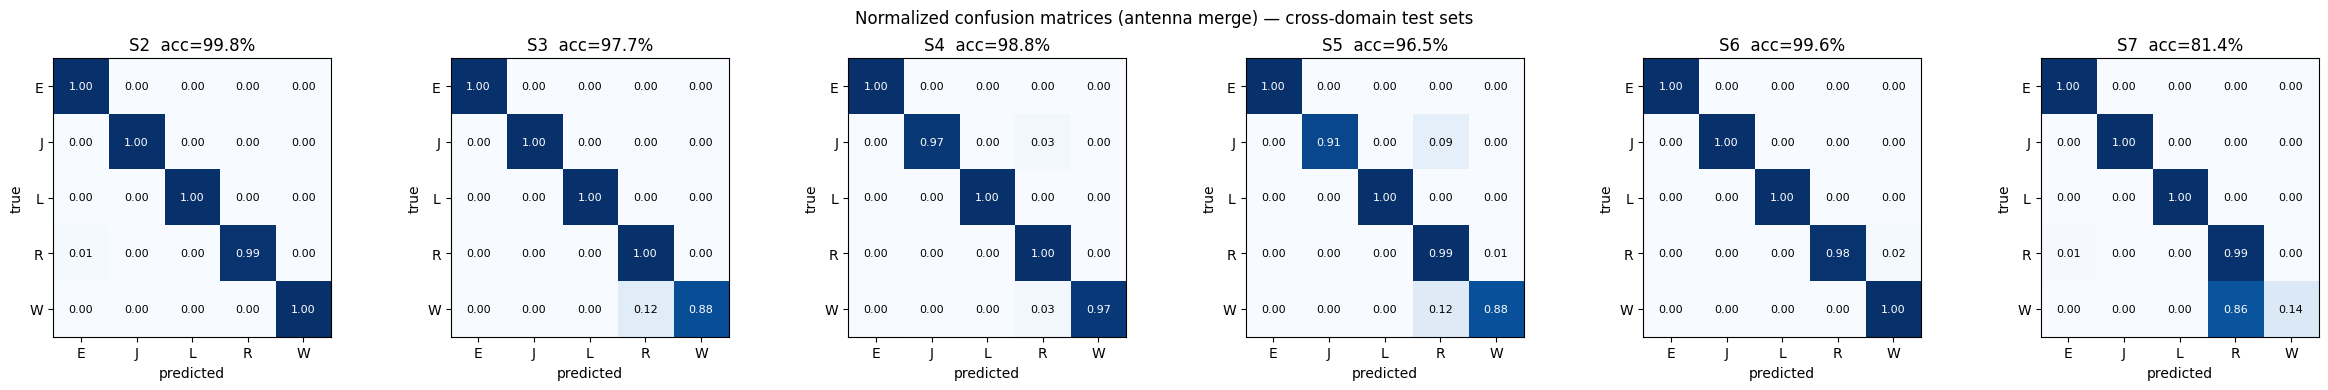

In [12]:
# --- normalized confusion matrices (antenna merge), one per test set: rows sum to 1, so each
#     row reads as "given the true activity, how it gets classified"
import matplotlib.pyplot as plt

class_names = list(activities)                 # ['E','J','L','R','W']
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.8))
if n == 1:
    axes = [axes]
for ax, (sid, r) in zip(axes, results.items()):
    cm = r['cm'].astype(float)
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)   # normalize by true class (row)
    im = ax.imshow(cmn, vmin=0, vmax=1, cmap='Blues')
    ax.set_title(f'{sid}  acc={r["acc_merge"] * 100:.1f}%')
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names)
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f'{cmn[i, j]:.2f}', ha='center', va='center',
                    color='white' if cmn[i, j] > 0.5 else 'black', fontsize=8)
fig.suptitle('Normalized confusion matrices (antenna merge) — cross-domain test sets')
fig.tight_layout()
plt.show()
